# 01 · Data preparation — §1

Draws the one split every model uses. **Run it in official mode once, early** — until its three files are committed, the other notebooks can only run in `synthetic` mode. In `synthetic` / `debug` mode it prepares and shows everything but writes nothing.

| | |
|---|---|
| **Owner** | Member 1 |
| **Reads** | EuroSAT via torchvision → `data/raw/` |
| **Writes (official)** | `data/splits/split_manifest.csv`, `split_meta.json`, `norm_stats.json`, `results/figures/dataset/*.png` |
| **Report needs** | dataset description + citation, split table, class distribution, sample images |

In [1]:
# ── Cell 1 · Colab bootstrap ─ does nothing when run locally ───────────────
# On a Colab runtime (in the browser, or from VS Code via the Colab extension) it
# clones REPO at BRANCH, installs it, and on every re-run pulls what you pushed since.
# Locally the package is already installed, so this is skipped. Guide: COLAB.md
import importlib.util
import sys

try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    import os
    import subprocess

    def _secret(name, default):  # your Colab Secret if you set one, else the default
        try:
            from google.colab import userdata

            return userdata.get(name) or default
        except Exception:  # not set, or unreadable here (VS Code cannot read Secrets)
            return default

    # The code to run is REPO @ BRANCH. Set your own fork / branch once, in Colab Secrets,
    # as A03_REPO / A03_BRANCH. In VS Code, edit the defaults below for the session and
    # put them back before committing. See COLAB.md.
    REPO = _secret("A03_REPO", "ThejithaR/EN3150-Assignment-03-CNN")
    BRANCH = _secret("A03_BRANCH", "main")
    REPO_DIR = "/content/en3150-a03"

    def _git(*args):  # never prompts: a failure shows as an error, not a hang
        subprocess.run(["git", *args], check=True, env={**os.environ, "GIT_TERMINAL_PROMPT": "0"})

    url = f"https://github.com/{REPO}.git"
    if not os.path.exists(REPO_DIR):
        _git("clone", "--quiet", "--branch", BRANCH, url, REPO_DIR)
    else:  # re-running this cell picks up everything pushed since
        _git("-C", REPO_DIR, "remote", "set-url", "origin", url)
        _git("-C", REPO_DIR, "fetch", "--quiet", "--prune", "origin")
        _git("-C", REPO_DIR, "checkout", "--quiet", "-B", BRANCH, f"origin/{BRANCH}")
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", REPO_DIR], check=True)
    if f"{REPO_DIR}/src" not in sys.path:
        sys.path.insert(0, f"{REPO_DIR}/src")  # an editable install is only seen after a restart
    os.chdir(REPO_DIR)
    _git("log", "--oneline", "-1")  # prints the exact commit this run uses

In [2]:
# ── Cell 2 · Setup ─────────────────────────────────────────────────────────
%load_ext autoreload
%autoreload 2

# MODE decides how much runs and whether anything is written:
#   "synthetic"  generated data, 2 epochs, seconds         - before EuroSAT exists
#   "debug"      5% of EuroSAT, 2 epochs                   - find bugs step by step
#   "official"   the full run - the ONLY mode that writes  - then Restart & Run All
MODE = "official"

from edgecnn.config import load_config
from edgecnn.contracts import paths, schema
from edgecnn.data import plot_class_distribution, plot_sample_grid, prepare_dataset, split_counts_table

In [3]:
# Shared figure style (Member 1): small inline figures, print-quality saved PNGs.
from edgecnn.evaluation.plotting import apply_style

apply_style()

## Config

Data settings are shared by every experiment, so any experiment file works here.

In [4]:
cfg = load_config("configs/experiments/model_b__adam.yaml", mode=MODE)
print(f"mode={cfg.mode}  official={cfg.is_official}")
print("dataset:", cfg.section("dataset")["name"], "| split:", cfg.section("split"))

mode=official  official=True
dataset: eurosat | split: {'train': 0.7, 'val': 0.15, 'test': 0.15, 'stratified': True, 'seed': 42}


## 1 · Prepare the dataset

Downloads EuroSAT, draws the stratified 70/15/15 split and computes train-only normalisation. An existing committed split is never overwritten (`force=False`). The first run downloads about 90 MB and decodes every image once, which takes a minute or two; later runs take seconds.

The printed SHA-256 is the split's fingerprint: the `debug` and `official` runs must print the same one.

In [5]:
prepared = prepare_dataset(cfg)
print(f"counts {prepared['meta']['counts']}  |  manifest SHA-256 {prepared['meta']['manifest_sha256'][:16]}")
written = [path.relative_to(paths.REPO_ROOT).as_posix() for path in prepared["written"]]
print("wrote:", ", ".join(written) if written else "nothing (only an official run without a committed split writes)")

counts {'train': 18900, 'val': 4050, 'test': 4050, 'total': 27000}  |  manifest SHA-256 9fc7491cc0b82660
wrote: data/splits/split_manifest.csv, data/splits/norm_stats.json, data/splits/split_meta.json


## 2 · Split sizes

Check the totals row shows 70 / 15 / 15, and no class has zero images in any split.

In [6]:
split_counts_table(prepared["meta"])

,train,val,test,total
class,,,,
AnnualCrop,2100,450,450,3000
Forest,2100,450,450,3000
HerbaceousVegetation,2100,450,450,3000
Highway,1750,375,375,2500
Industrial,1750,375,375,2500
Pasture,1400,300,300,2000
PermanentCrop,1750,375,375,2500
Residential,2100,450,450,3000
River,1750,375,375,2500


## 3 · Class distribution

The bars for each class should have the same proportions in every split.

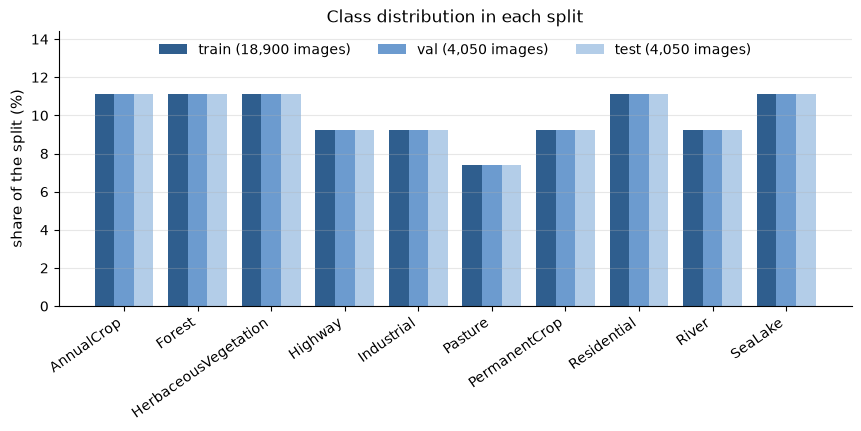

In [7]:
plot_class_distribution(prepared["meta"], write=cfg.is_official)

## 4 · Sample images

What the models actually see: 64×64, no augmentation.

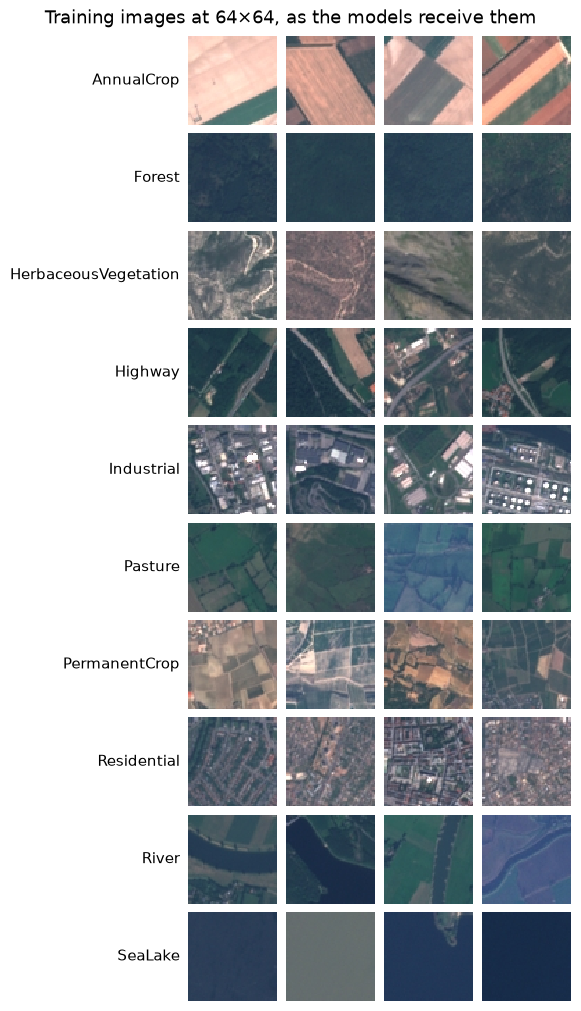

In [8]:
plot_sample_grid(cfg, per_class=4, write=cfg.is_official)

## 5 · Normalisation statistics

`fitted_on` must be `train`.

In [9]:
prepared["norm_stats"]

{'mean': [0.34390074678501115, 0.37995412566269177, 0.4075493409117746],
 'std': [0.20242460538119916, 0.13668293751641206, 0.11540833380045462],
 'fitted_on': 'train',
 'num_images': 18900}

## 6 · Validate the committed files

Only meaningful after an official run has written them.

In [10]:
if paths.SPLIT_MANIFEST.exists():
    rows = schema.validate_manifest(paths.SPLIT_MANIFEST)
    meta = schema.read_json(paths.SPLIT_META, "split_meta")
    schema.read_json(paths.NORM_STATS, "norm_stats")
    print(f"valid: {rows} manifest rows, {meta['num_classes']} classes, counts {meta['counts']}")
else:
    print("No committed split yet - run this notebook with MODE = 'official'.")

valid: 27000 manifest rows, 10 classes, counts {'train': 18900, 'val': 4050, 'test': 4050, 'total': 27000}


## Official-run checklist

- [ ] `MODE = "official"` in the setup cell
- [ ] Kernel → **Restart & Run All** finished without errors
- [ ] every output is what you expect — no stray warnings or giant prints
- [ ] announce in the group chat that the split is committed — everyone can leave `synthetic`
- [ ] `pytest tests/contracts` is green
- [ ] commit this notebook **with its outputs**, together with the files it wrote

In [11]:
# ── Colab only: send this run's results back to GitHub ─────────────────────
# Does nothing locally, or in synthetic / debug mode. Guide: COLAB.md
if IN_COLAB and MODE == "official":
    from edgecnn.utils import push_results

    push_results(
        [paths.SPLITS_DIR, paths.DATASET_FIGURES_DIR],
        "Add EuroSAT split (Colab)",
    )